In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:
dataset = fetch_ucirepo(id=365)
X = dataset.data.features
y = dataset.data.targets

In [3]:
df = X.copy()
df['class'] = y['class']

print(f"Full dataset shape: {df.shape}")
print(f"Years available: {sorted(df['year'].unique())}")
print()

for year in sorted(df['year'].unique()):
    subset = df[df['year'] == year]
    n = len(subset)
    n_bankrupt = (subset['class'] == 1).sum()
    n_missing = subset.drop(columns=['class']).isnull().sum().sum()
    n_cells = subset.drop(columns=['class', 'year']).size
    print(f"Year {year}: {n} rows, "
          f"bankrupt {n_bankrupt} ({100*n_bankrupt/n:.1f}%), "
          f"missing {n_missing} ({100*n_missing/n_cells:.1f}% cells)")

Full dataset shape: (43405, 66)
Years available: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Year 1: 7027 rows, bankrupt 271 (3.9%), missing 5835 (1.3% cells)
Year 2: 10173 rows, bankrupt 400 (3.9%), missing 12157 (1.9% cells)
Year 3: 10503 rows, bankrupt 495 (4.7%), missing 9888 (1.5% cells)
Year 4: 9792 rows, bankrupt 515 (5.3%), missing 8776 (1.4% cells)
Year 5: 5910 rows, bankrupt 410 (6.9%), missing 4666 (1.2% cells)


In [4]:
missing_by_col = X.drop(columns=['year']).isnull().sum().sort_values(ascending=False)
missing_pct = (missing_by_col / len(X) * 100).round(1)

print("Columns with missing values:")
print(missing_pct[missing_pct > 0].to_string())
print(f"\nColumns with no missing: {(missing_pct == 0).sum()} / {len(missing_pct)}")

Columns with missing values:
A37    43.7
A21    13.5
A27     6.4
A60     5.0
A45     4.9
A24     2.1
A28     1.9
A64     1.9
A53     1.9
A54     1.9
A41     1.7
A32     0.8
A52     0.7
A47     0.7
A46     0.3
A40     0.3
A63     0.3
A33     0.3
A4      0.3
A12     0.3
A19     0.3
A31     0.3
A62     0.3
A56     0.3
A49     0.3
A44     0.3
A43     0.3
A20     0.3
A39     0.3
A13     0.3
A42     0.3
A30     0.3
A23     0.3
A61     0.2
A16     0.2
A26     0.2
A34     0.2
A50     0.2
A17     0.2
A8      0.2
A5      0.2
A58     0.2
A11     0.1
A15     0.1

Columns with no missing: 20 / 64


In [7]:
df = X.copy()
df['class'] = y['class']
df = df[df['year'] == 4].drop(columns=['year'])

X = df.drop(columns=['class'])
y = df['class']

print(f"Shape: {X.shape}")
print(f"Bankrupt: {(y==1).sum()} ({100*(y==1).mean():.1f}%)")
print(f"Not bankrupt: {(y==0).sum()} ({100*(y==0).mean():.1f}%)")
print(f"\nMissing values: {X.isnull().sum().sum()} ({100*X.isnull().sum().sum()/X.size:.1f}% cells)")

Shape: (9792, 64)
Bankrupt: 515 (5.3%)
Not bankrupt: 9277 (94.7%)

Missing values: 8776 (1.4% cells)


In [8]:
desc = X.describe().T
desc['missing_%'] = (X.isnull().sum() / len(X) * 100).round(1)

print(desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'missing_%']].to_string())

      count         mean            std           min         25%         50%          75%           max  missing_%
A1   9791.0     0.043019       0.359321 -1.245800e+01    0.001321    0.041364     0.111130  2.048200e+01        0.0
A2   9791.0     0.596404       4.587122  0.000000e+00    0.263145    0.467740     0.689255  4.469100e+02        0.0
A3   9791.0     0.130959       4.559074 -4.459100e+02    0.020377    0.199290     0.410670  2.276900e+01        0.0
A4   9749.0     8.136600     290.647281 -4.531900e-02    1.047000    1.591800     2.880400  2.714600e+04        0.4
A5   9771.0    64.255566   14732.269541 -3.790000e+05  -51.217000   -0.055576    55.732000  1.030000e+06        0.2
A6   9791.0    -0.059273       6.812754 -4.868200e+02   -0.000578    0.000000     0.065322  3.222000e+02        0.0
A7   9791.0     0.059446       0.533344 -1.245800e+01    0.003004    0.048820     0.126940  3.861800e+01        0.0
A8   9773.0    19.884016     698.697015 -1.848200e+00    0.428300    1.0

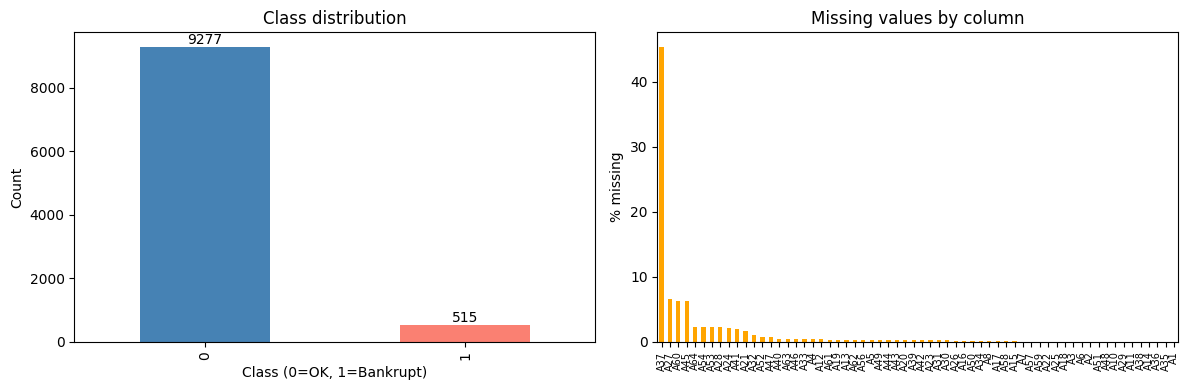

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
y.value_counts().plot.bar(ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Class distribution')
axes[0].set_xlabel('Class (0=OK, 1=Bankrupt)')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

# Missing values per column
missing = (X.isnull().sum() / len(X) * 100).sort_values(ascending=False)
missing = missing[missing > 0]
missing.plot.bar(ax=axes[1], color='orange')
axes[1].set_title('Missing values by column')
axes[1].set_ylabel('% missing')
axes[1].tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.show()

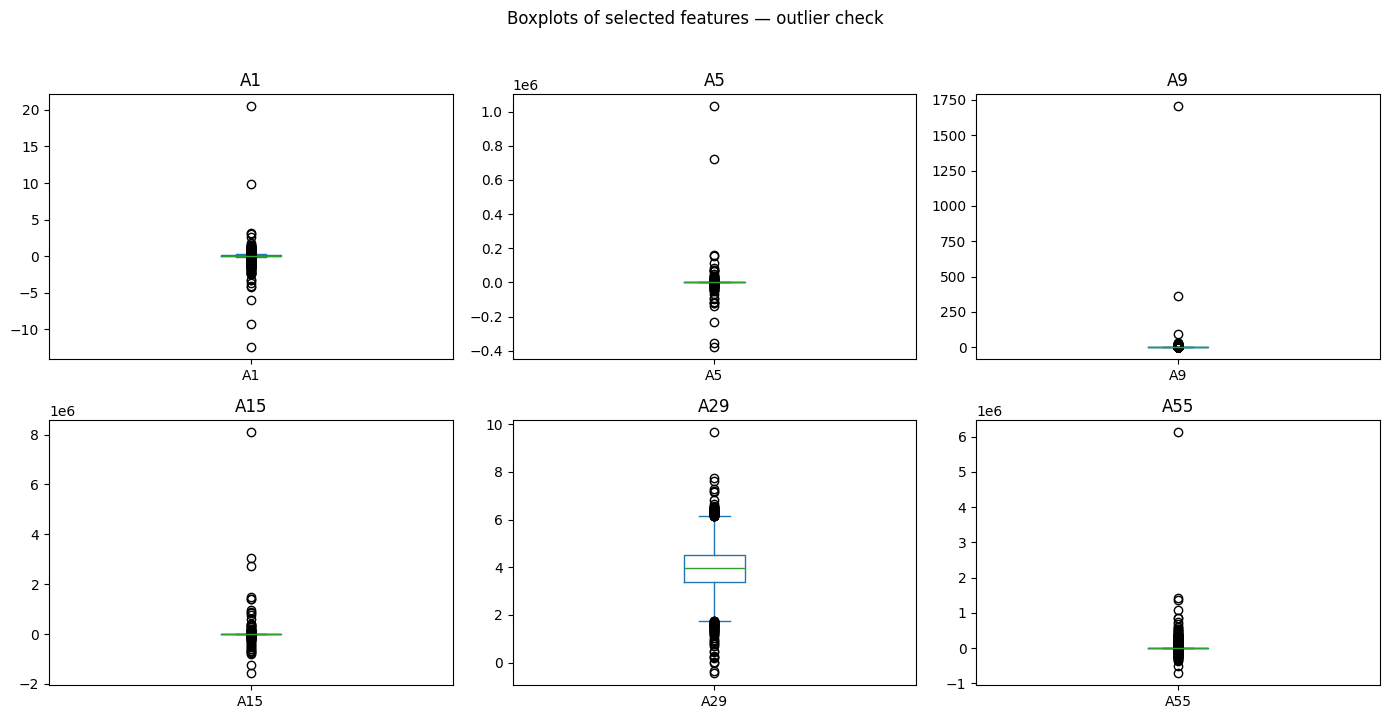

In [10]:
sample_cols = ['A1', 'A5', 'A9', 'A15', 'A29', 'A55']
# A1  = net profit / total assets (powinien byc ~0-1)
# A5  = cash flow ratio * 365 (ten z max=1mln)
# A9  = sales / total assets
# A15 = liabilities*365 / (profit+depreciation)
# A29 = log(total assets) - jedyny logarytm
# A55 = working capital (raw, not ratio)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), sample_cols):
    X[col].plot.box(ax=ax)
    ax.set_title(col)

plt.suptitle('Boxplots of selected features — outlier check', y=1.02)
plt.tight_layout()
plt.show()

Usuwamy A37, bo przy 45% braków imputacja medianą stworzyłaby sztuczny rozkład, a informację o płynności pokrywają inne kolumny (A46, A50, A4).

In [11]:
X = X.drop(columns=['A37'])
print("Shape after dropping A37:", X.shape)
print("Remaining missing:", X.isnull().sum().sum())

Shape after dropping A37: (9792, 63)
Remaining missing: 4334


In [12]:
missing_per_row = X.isnull().sum(axis=1)

print("Rows with any missing value:", (missing_per_row > 0).sum())
print()
print("Avg missing features per row:")
print(f"  Class 0 (OK):       {missing_per_row[y==0].mean():.2f}")
print(f"  Class 1 (Bankrupt): {missing_per_row[y==1].mean():.2f}")

Rows with any missing value: 1701

Avg missing features per row:
  Class 0 (OK):       0.41
  Class 1 (Bankrupt): 1.04


- TODO CZEMU NIE MEDIANA PER KLASA 

In [13]:
print("Missing before imputation:", X.isnull().sum().sum())

X = X.fillna(X.median())

print("Missing after imputation:", X.isnull().sum().sum())
print("Shape:", X.shape)

Missing before imputation: 4334
Missing after imputation: 0
Shape: (9792, 63)


In [14]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (X < Q1 - 1.5 * IQR) | (X > Q3 + 1.5 * IQR)

print(f"Total outlier cells: {outlier_mask.sum().sum()} "
      f"({100 * outlier_mask.sum().sum() / X.size:.1f}% of all data)")
print(f"Rows with at least 1 outlier: {outlier_mask.any(axis=1).sum()} "
      f"({100 * outlier_mask.any(axis=1).mean():.0f}% of rows)")

Total outlier cells: 68177 (11.1% of all data)
Rows with at least 1 outlier: 8801 (90% of rows)


In [15]:
X_clipped = X.clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR, axis=1)

# check how much changed
outlier_after = ((X_clipped < Q1 - 1.5*IQR) | (X_clipped > Q3 + 1.5*IQR)).sum().sum()
print(f"Outlier cells after clipping: {outlier_after}")
print(f"Shape unchanged: {X_clipped.shape}")

Outlier cells after clipping: 0
Shape unchanged: (9792, 63)


In [18]:
X = X_clipped.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Mean (first 5 cols): {X_scaled.mean(axis=0)[:5].round(6)}")
print(f"Std  (first 5 cols): {X_scaled.std(axis=0)[:5].round(6)}")

Mean (first 5 cols): [-0.  0.  0.  0.  0.]
Std  (first 5 cols): [1. 1. 1. 1. 1.]


/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_94454/387479283.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


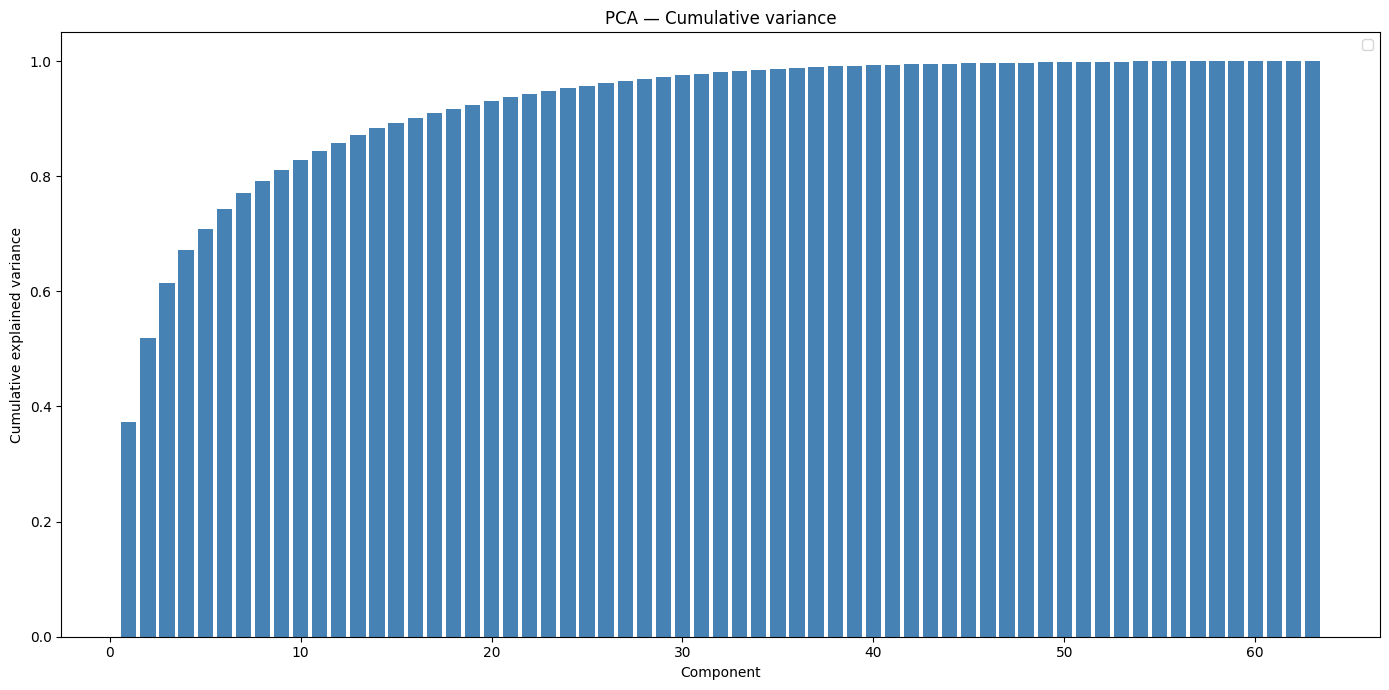

Components for 90% variance: 16
First 2 components explain: 51.9%

  PC 1:  37.3%  (cumulative:  37.3%)
  PC 2:  14.6%  (cumulative:  51.9%)
  PC 3:   9.5%  (cumulative:  61.5%)
  PC 4:   5.8%  (cumulative:  67.3%)
  PC 5:   3.6%  (cumulative:  70.9%)
  PC 6:   3.5%  (cumulative:  74.3%)
  PC 7:   2.7%  (cumulative:  77.1%)
  PC 8:   2.1%  (cumulative:  79.2%)
  PC 9:   1.9%  (cumulative:  81.1%)
  PC10:   1.7%  (cumulative:  82.8%)
  PC11:   1.6%  (cumulative:  84.3%)
  PC12:   1.5%  (cumulative:  85.8%)
  PC13:   1.4%  (cumulative:  87.2%)
  PC14:   1.1%  (cumulative:  88.3%)
  PC15:   1.0%  (cumulative:  89.3%)
  PC16:   0.9%  (cumulative:  90.2%)
  PC17:   0.8%  (cumulative:  91.0%)
  PC18:   0.8%  (cumulative:  91.7%)
  PC19:   0.7%  (cumulative:  92.4%)
  PC20:   0.7%  (cumulative:  93.1%)
  PC21:   0.6%  (cumulative:  93.7%)
  PC22:   0.5%  (cumulative:  94.3%)
  PC23:   0.5%  (cumulative:  94.8%)
  PC24:   0.5%  (cumulative:  95.3%)
  PC25:   0.4%  (cumulative:  95.7%)
  PC26: 

In [25]:
from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(X_scaled)

var_ratio = pca_full.explained_variance_ratio_
cumvar = var_ratio.cumsum()

plt.figure(figsize=(14, 7))
plt.bar(range(1, len(cumvar)+1), cumvar, color='steelblue')
plt.xlabel('Component')
plt.ylabel('Cumulative explained variance')
plt.title('PCA — Cumulative variance')
plt.legend()
plt.tight_layout()
plt.show()

n90 = (cumvar >= 0.90).argmax() + 1
print(f"Components for 90% variance: {n90}")
print(f"First 2 components explain: {cumvar[1]*100:.1f}%")
print()
for i in range(min(500, len(var_ratio))):
    print(f"  PC{i+1:2d}: {var_ratio[i]*100:5.1f}%  (cumulative: {cumvar[i]*100:5.1f}%)")

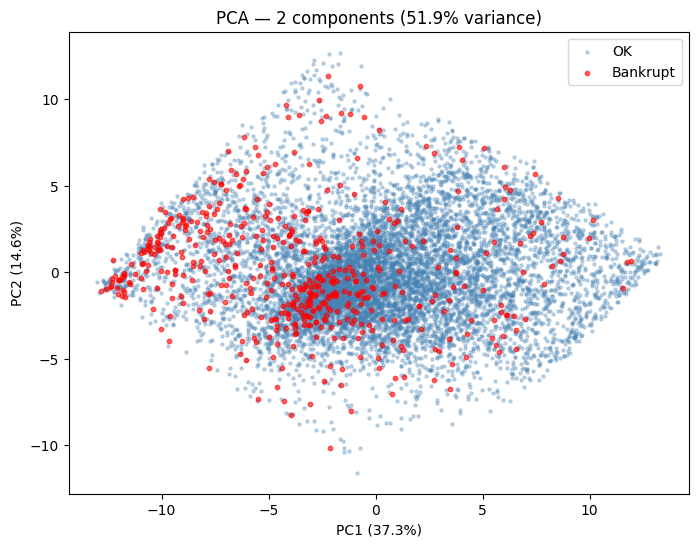

In [26]:
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[y==0, 0], X_pca[y==0, 1], c='steelblue', alpha=0.3, s=5, label='OK')
plt.scatter(X_pca[y==1, 0], X_pca[y==1, 1], c='red', alpha=0.6, s=10, label='Bankrupt')
plt.xlabel(f'PC1 ({var_ratio[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({var_ratio[1]*100:.1f}%)')
plt.title('PCA — 2 components (51.9% variance)')
plt.legend()
plt.show()

- TODO czemu tsne i potoki to nie nauczyc sie 

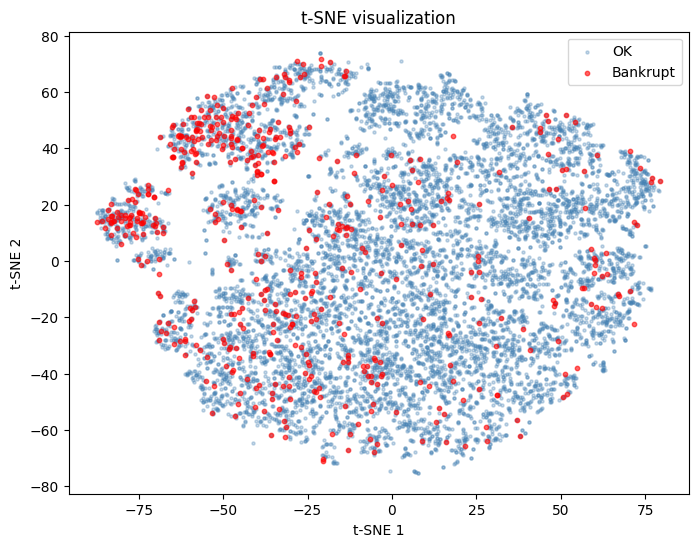

In [27]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[y==0, 0], X_tsne[y==0, 1], c='steelblue', alpha=0.3, s=5, label='OK')
plt.scatter(X_tsne[y==1, 0], X_tsne[y==1, 1], c='red', alpha=0.6, s=10, label='Bankrupt')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE visualization')
plt.legend()
plt.show()

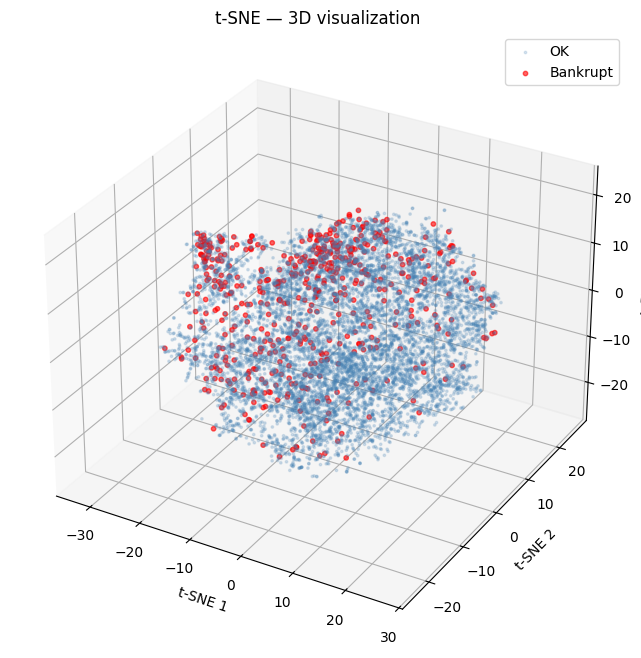

In [28]:
from mpl_toolkits.mplot3d import Axes3D

tsne3d = TSNE(n_components=3, random_state=42, perplexity=30)
X_tsne3d = tsne3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_tsne3d[y==0, 0], X_tsne3d[y==0, 1], X_tsne3d[y==0, 2],
           c='steelblue', alpha=0.2, s=3, label='OK')
ax.scatter(X_tsne3d[y==1, 0], X_tsne3d[y==1, 1], X_tsne3d[y==1, 2],
           c='red', alpha=0.6, s=10, label='Bankrupt')

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')
ax.set_title('t-SNE — 3D visualization')
ax.legend()
plt.show()

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows, bankrupt: {(y_train==1).sum()} ({100*(y_train==1).mean():.1f}%)")
print(f"Test:  {X_test.shape[0]} rows, bankrupt: {(y_test==1).sum()} ({100*(y_test==1).mean():.1f}%)")

Train: 7833 rows, bankrupt: 412 (5.3%)
Test:  1959 rows, bankrupt: 103 (5.3%)


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models = {
    'Logistic Regression':       LogisticRegression(max_iter=1000, random_state=42),
    'Logistic (balanced)':       LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree':             DecisionTreeClassifier(random_state=42),
    'Decision Tree (balanced)':  DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest':             RandomForestClassifier(n_estimators=100, random_state=42),
    'Random Forest (balanced)':  RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting':         GradientBoostingClassifier(n_estimators=100, random_state=42),
    'KNN (k=5)':                 KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)':                 SVC(random_state=42),
    'SVM (RBF, balanced)':       SVC(random_state=42, class_weight='balanced'),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision(1)': precision_score(y_test, y_pred, zero_division=0),
        'Recall(1)': recall_score(y_test, y_pred, zero_division=0),
        'F1(1)': f1_score(y_test, y_pred, zero_division=0),
    })

results_df = pd.DataFrame(results).sort_values('Recall(1)', ascending=False)
print(results_df.to_string(index=False))

                   Model  Accuracy  Precision(1)  Recall(1)    F1(1)
     Logistic (balanced)  0.758040      0.132673   0.650485 0.220395
     SVM (RBF, balanced)  0.805513      0.152500   0.592233 0.242545
           Decision Tree  0.921388      0.289256   0.339806 0.312500
       Gradient Boosting  0.962226      0.853659   0.339806 0.486111
Decision Tree (balanced)  0.933640      0.354839   0.320388 0.336735
           Random Forest  0.948954      0.636364   0.067961 0.122807
Random Forest (balanced)  0.948954      0.666667   0.058252 0.107143
     Logistic Regression  0.946912      0.444444   0.038835 0.071429
               KNN (k=5)  0.942828      0.153846   0.019417 0.034483
               SVM (RBF)  0.947422      0.000000   0.000000 0.000000


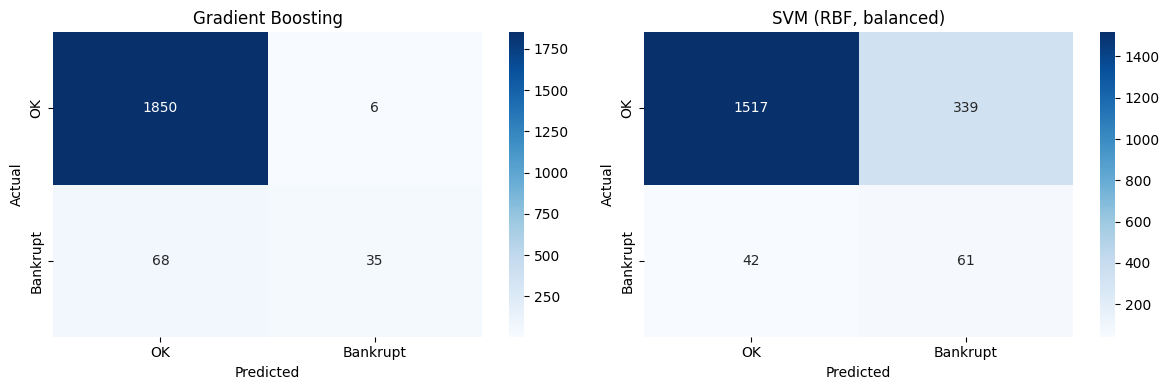

GRADIENT BOOSTING
              precision    recall  f1-score   support

          OK       0.96      1.00      0.98      1856
    Bankrupt       0.85      0.34      0.49       103

    accuracy                           0.96      1959
   macro avg       0.91      0.67      0.73      1959
weighted avg       0.96      0.96      0.95      1959

SVM (RBF, balanced)
              precision    recall  f1-score   support

          OK       0.97      0.82      0.89      1856
    Bankrupt       0.15      0.59      0.24       103

    accuracy                           0.81      1959
   macro avg       0.56      0.70      0.57      1959
weighted avg       0.93      0.81      0.85      1959



In [31]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model_gb = models['Gradient Boosting']
model_svm = models['SVM (RBF, balanced)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, name in zip(axes, [model_gb, model_svm], 
                            ['Gradient Boosting', 'SVM (RBF, balanced)']):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['OK', 'Bankrupt'], yticklabels=['OK', 'Bankrupt'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(name)

plt.tight_layout()
plt.show()

print("=" * 60)
print("GRADIENT BOOSTING")
print("=" * 60)
print(classification_report(y_test, model_gb.predict(X_test), 
                            target_names=['OK', 'Bankrupt']))

print("=" * 60)
print("SVM (RBF, balanced)")
print("=" * 60)
print(classification_report(y_test, model_svm.predict(X_test),
                            target_names=['OK', 'Bankrupt']))

In [34]:
y_proba = model_gb.predict_proba(X_test)[:, 1]

print(f"{'Threshold':<12} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 45)

for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_pred_t = (y_proba >= t).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    print(f"{t:<12} {p:>10.3f} {r:>10.3f} {f:>10.3f}")

Threshold     Precision     Recall         F1
---------------------------------------------
0.5               0.854      0.340      0.486
0.4               0.854      0.398      0.543
0.3               0.794      0.485      0.602
0.2               0.616      0.515      0.561
0.1               0.352      0.612      0.447


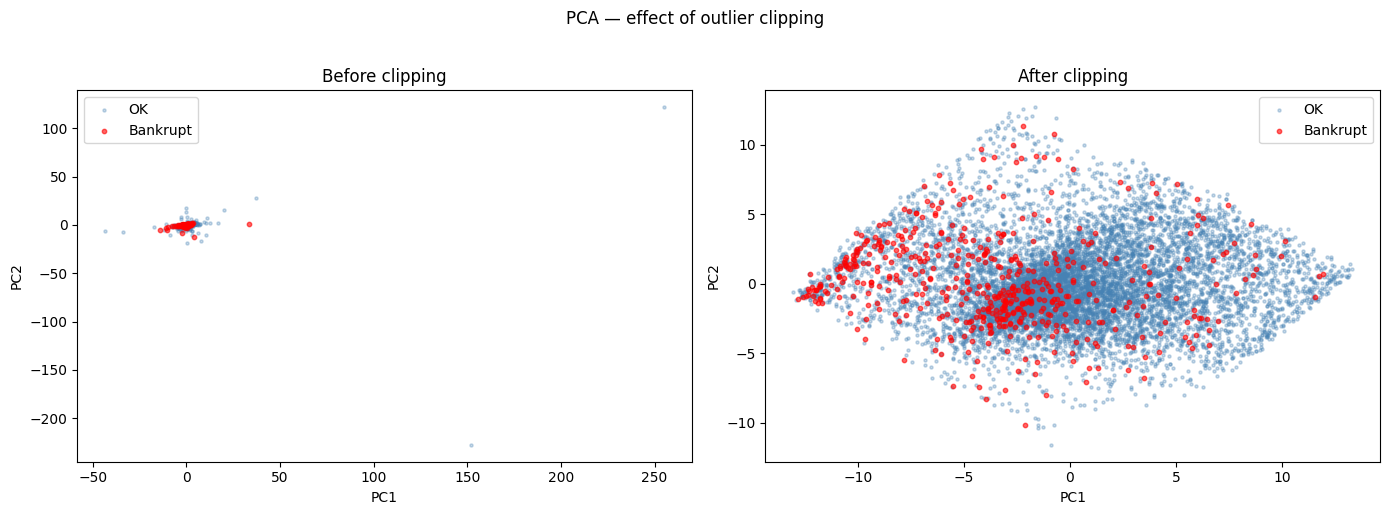

In [35]:
# Recreate data before clipping (after imputation but before clip)
df_raw = dataset.data.features.copy()
df_raw['class'] = dataset.data.targets['class']
df_raw = df_raw[df_raw['year'] == 4].drop(columns=['year'])
X_raw = df_raw.drop(columns=['class'])
X_raw = X_raw.drop(columns=['A37'])
X_raw = X_raw.fillna(X_raw.median())

# Scale both versions
from sklearn.preprocessing import StandardScaler
scaler_raw = StandardScaler()
X_raw_scaled = scaler_raw.fit_transform(X_raw)

# PCA on both
pca_before = PCA(n_components=2).fit_transform(X_raw_scaled)
pca_after = PCA(n_components=2).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in zip(axes, [pca_before, pca_after],
                            ['Before clipping', 'After clipping']):
    ax.scatter(data[y==0, 0], data[y==0, 1], c='steelblue', alpha=0.3, s=5, label='OK')
    ax.scatter(data[y==1, 0], data[y==1, 1], c='red', alpha=0.6, s=10, label='Bankrupt')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(title)
    ax.legend()

plt.suptitle('PCA — effect of outlier clipping', y=1.02)
plt.tight_layout()
plt.show()

In [36]:
# Recreate data before clipping
df_raw = dataset.data.features.copy()
df_raw['class'] = dataset.data.targets['class']
df_raw = df_raw[df_raw['year'] == 4].drop(columns=['year'])
X_raw = df_raw.drop(columns=['class'])
X_raw = X_raw.drop(columns=['A37'])
X_raw = X_raw.fillna(X_raw.median())

scaler_raw = StandardScaler()
X_raw_scaled = scaler_raw.fit_transform(X_raw)

X_train_raw, X_test_raw, _, _ = train_test_split(
    X_raw_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Compare models: before vs after clipping
print(f"{'Model':<28} {'Data':<18} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 80)

for name, Model, params in [
    ('Gradient Boosting', GradientBoostingClassifier, dict(n_estimators=100, random_state=42)),
    ('SVM (RBF, balanced)', SVC, dict(random_state=42, class_weight='balanced')),
]:
    for label, Xtr, Xte in [
        ('Before clipping', X_train_raw, X_test_raw),
        ('After clipping', X_train, X_test),
    ]:
        m = Model(**params)
        m.fit(Xtr, y_train)
        yp = m.predict(Xte)
        p = precision_score(y_test, yp, zero_division=0)
        r = recall_score(y_test, yp, zero_division=0)
        f = f1_score(y_test, yp, zero_division=0)
        print(f"{name:<28} {label:<18} {p:>10.3f} {r:>10.3f} {f:>10.3f}")
    print()

Model                        Data                Precision     Recall         F1
--------------------------------------------------------------------------------
Gradient Boosting            Before clipping         0.944      0.330      0.489
Gradient Boosting            After clipping          0.854      0.340      0.486

SVM (RBF, balanced)          Before clipping         0.125      0.515      0.201
SVM (RBF, balanced)          After clipping          0.152      0.592      0.243



In [37]:
from sklearn.preprocessing import MinMaxScaler

scaler_mm = MinMaxScaler()
X_minmax = scaler_mm.fit_transform(X)

X_train_mm, X_test_mm, _, _ = train_test_split(
    X_minmax, y, test_size=0.2, random_state=42, stratify=y
)

print(f"{'Model':<28} {'Scaling':<18} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 80)

for name, Model, params in [
    ('Gradient Boosting', GradientBoostingClassifier, dict(n_estimators=100, random_state=42)),
    ('SVM (RBF, balanced)', SVC, dict(random_state=42, class_weight='balanced')),
]:
    for label, Xtr, Xte in [
        ('Z-score', X_train, X_test),
        ('Min-Max', X_train_mm, X_test_mm),
    ]:
        m = Model(**params)
        m.fit(Xtr, y_train)
        yp = m.predict(Xte)
        p = precision_score(y_test, yp, zero_division=0)
        r = recall_score(y_test, yp, zero_division=0)
        f = f1_score(y_test, yp, zero_division=0)
        print(f"{name:<28} {label:<18} {p:>10.3f} {r:>10.3f} {f:>10.3f}")
    print()

Model                        Scaling             Precision     Recall         F1
--------------------------------------------------------------------------------
Gradient Boosting            Z-score                 0.854      0.340      0.486
Gradient Boosting            Min-Max                 0.854      0.340      0.486

SVM (RBF, balanced)          Z-score                 0.152      0.592      0.243
SVM (RBF, balanced)          Min-Max                 0.145      0.583      0.233



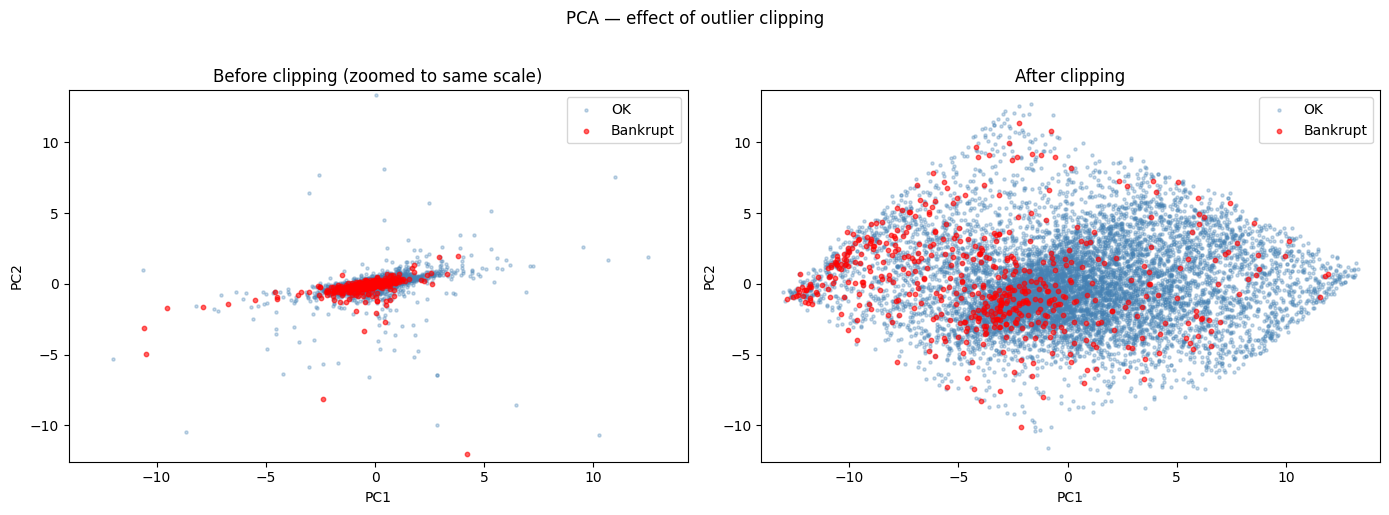

In [38]:
pca_before = PCA(n_components=2).fit_transform(X_raw_scaled)
pca_after = PCA(n_components=2).fit_transform(X_scaled)

# Use after-clipping range for both plots
xlim = (pca_after[:, 0].min() - 1, pca_after[:, 0].max() + 1)
ylim = (pca_after[:, 1].min() - 1, pca_after[:, 1].max() + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in zip(axes, [pca_before, pca_after],
                            ['Before clipping (zoomed to same scale)', 'After clipping']):
    ax.scatter(data[y==0, 0], data[y==0, 1], c='steelblue', alpha=0.3, s=5, label='OK')
    ax.scatter(data[y==1, 0], data[y==1, 1], c='red', alpha=0.6, s=10, label='Bankrupt')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(title)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.legend()

plt.suptitle('PCA — effect of outlier clipping', y=1.02)
plt.tight_layout()
plt.show()

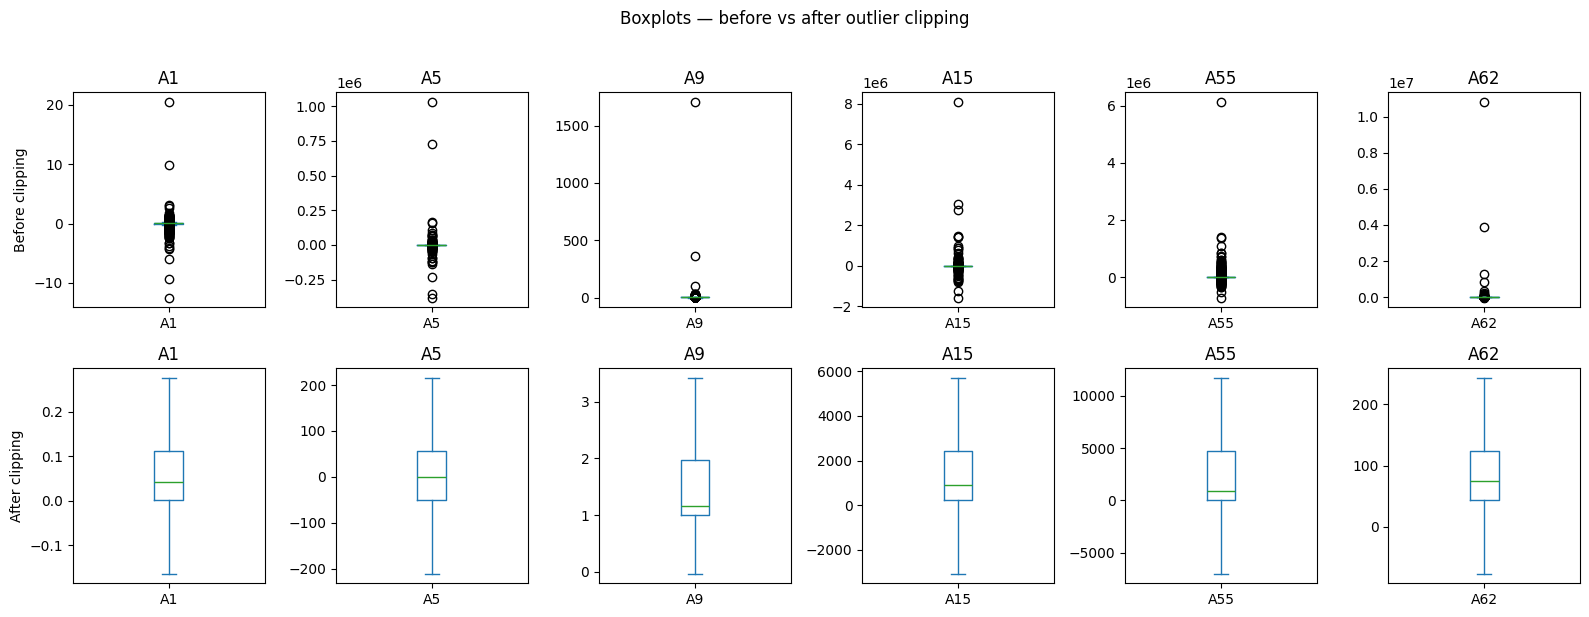

In [39]:
sample_cols = ['A1', 'A5', 'A9', 'A15', 'A55', 'A62']

fig, axes = plt.subplots(2, len(sample_cols), figsize=(16, 6))

for i, col in enumerate(sample_cols):
    X_raw[col].plot.box(ax=axes[0, i])
    axes[0, i].set_title(col)
    
    X[col].plot.box(ax=axes[1, i])
    axes[1, i].set_title(col)

axes[0, 0].set_ylabel('Before clipping')
axes[1, 0].set_ylabel('After clipping')

plt.suptitle('Boxplots — before vs after outlier clipping', y=1.02)
plt.tight_layout()
plt.show()

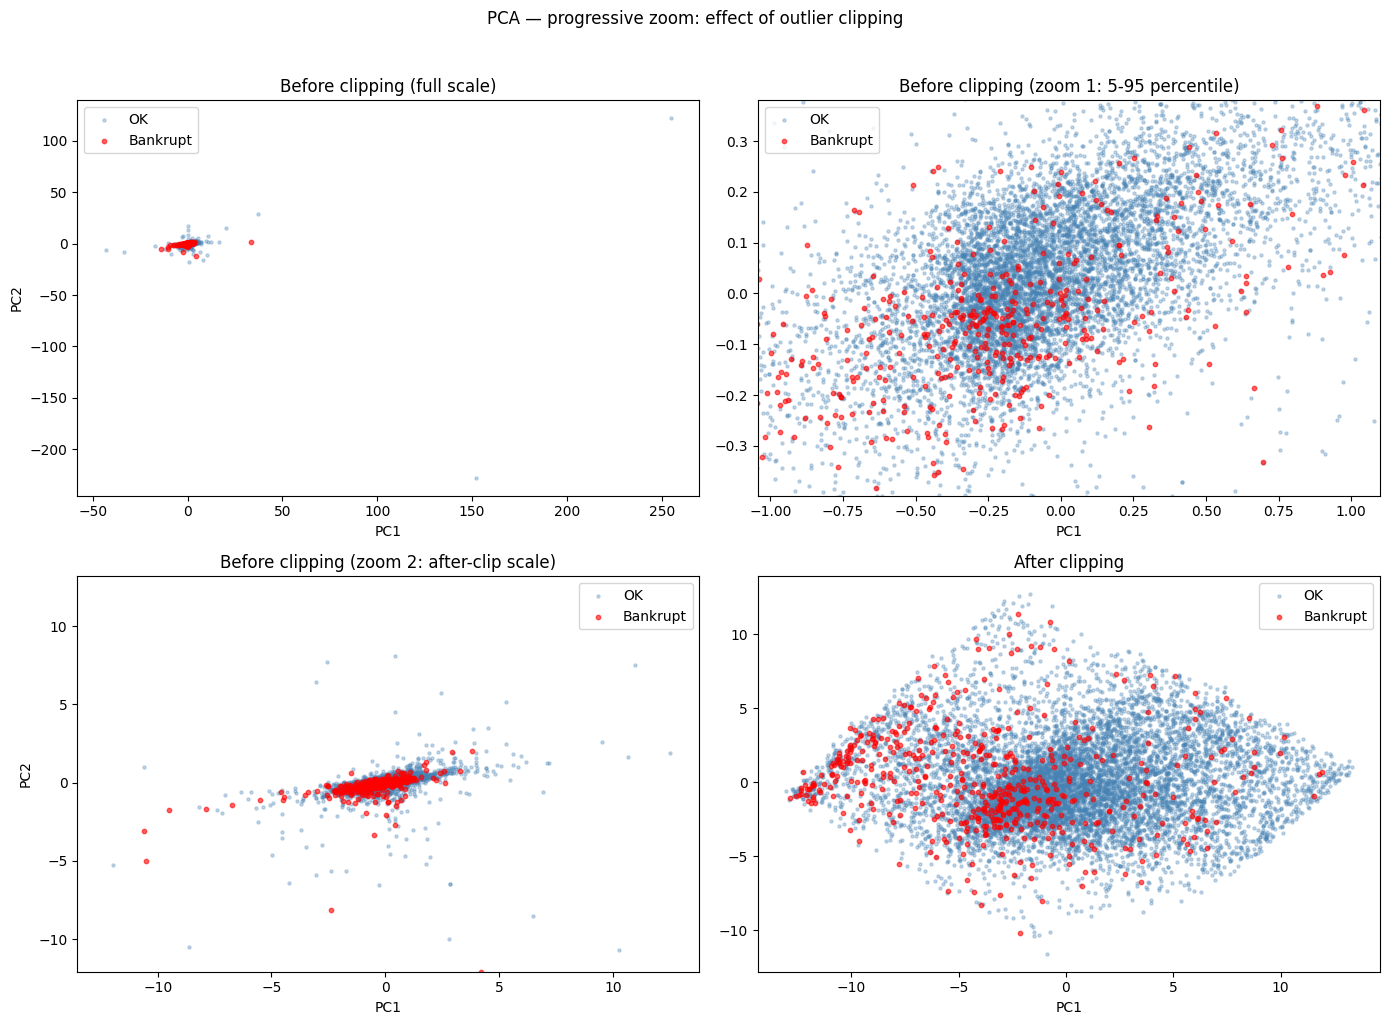

In [44]:
pca_before = PCA(n_components=2).fit_transform(X_raw_scaled)
pca_after = PCA(n_components=2).fit_transform(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Before — full scale
axes[0,0].scatter(pca_before[y==0, 0], pca_before[y==0, 1], c='steelblue', alpha=0.3, s=5, label='OK')
axes[0,0].scatter(pca_before[y==1, 0], pca_before[y==1, 1], c='red', alpha=0.6, s=10, label='Bankrupt')
axes[0,0].set_title('Before clipping (full scale)')
axes[0,0].set_xlabel('PC1')
axes[0,0].set_ylabel('PC2')
axes[0,0].legend()

# 2) Before — zoom level 1 (5th-95th percentile)
axes[0,1].scatter(pca_before[y==0, 0], pca_before[y==0, 1], c='steelblue', alpha=0.3, s=5, label='OK')
axes[0,1].scatter(pca_before[y==1, 0], pca_before[y==1, 1], c='red', alpha=0.6, s=10, label='Bankrupt')
axes[0,1].set_title('Before clipping (zoom 1: 5-95 percentile)')
axes[0,1].set_xlabel('PC1')
axes[0,1].set_xlim(np.percentile(pca_before[:, 0], 5), np.percentile(pca_before[:, 0], 95))
axes[0,1].set_ylim(np.percentile(pca_before[:, 1], 5), np.percentile(pca_before[:, 1], 95))
axes[0,1].legend()

# 3) Before — zoom level 2 (same scale as after clipping)
axes[1,0].scatter(pca_before[y==0, 0], pca_before[y==0, 1], c='steelblue', alpha=0.3, s=5, label='OK')
axes[1,0].scatter(pca_before[y==1, 0], pca_before[y==1, 1], c='red', alpha=0.6, s=10, label='Bankrupt')
axes[1,0].set_title('Before clipping (zoom 2: after-clip scale)')
axes[1,0].set_xlabel('PC1')
axes[1,0].set_ylabel('PC2')
axes[1,0].set_xlim(pca_after[:, 0].min() - 0.5, pca_after[:, 0].max() + 0.5)
axes[1,0].set_ylim(pca_after[:, 1].min() - 0.5, pca_after[:, 1].max() + 0.5)
axes[1,0].legend()

# 4) After clipping
axes[1,1].scatter(pca_after[y==0, 0], pca_after[y==0, 1], c='steelblue', alpha=0.3, s=5, label='OK')
axes[1,1].scatter(pca_after[y==1, 0], pca_after[y==1, 1], c='red', alpha=0.6, s=10, label='Bankrupt')
axes[1,1].set_title('After clipping')
axes[1,1].set_xlabel('PC1')
axes[1,1].legend()

plt.suptitle('PCA — progressive zoom: effect of outlier clipping', y=1.02)
plt.tight_layout()
plt.show()